# Distribution Concepts in Quant Finance for Beginners

This notebook introduces the most important distribution ideas used in quantitative finance. The goal is to build intuition before going into advanced modelling.

## What you will learn

- what a distribution means in finance
- why quants care about the shape of returns
- the difference between symmetric, skewed, and fat-tailed distributions
- how to interpret skewness and kurtosis
- which distribution types appear often in finance

## Beginner intuition

A distribution is a picture of how values are spread out. In finance, those values are often daily returns, monthly returns, losses, or asset prices. If you understand the distribution, you understand what outcomes are common, what outcomes are rare, and how severe extreme moves can be.

## 1. Why Distributions Matter in Quant Finance

A distribution helps answer practical questions such as:

- What is a typical daily return?
- How likely is a very large loss?
- Are upside and downside moves balanced?
- Do extreme events happen more often than a normal model predicts?

In portfolio management, option pricing, risk management, and backtesting, distribution assumptions affect decisions directly.

### Beginner explanation

Think of a distribution as the market's "behavior pattern." Two assets can have the same average return but very different risk if one has heavy crash risk or strong downside skew.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("deep")
rng = np.random.default_rng(42)

sample_size = 5000
mean_daily = 0.0004
vol_daily = 0.012

def sample_kurtosis(x):
    return stats.kurtosis(x, fisher=False, bias=False)

def sample_summary(x, name):
    return {
        "Distribution": name,
        "Mean": np.mean(x),
        "Std Dev": np.std(x, ddof=1),
        "Skewness": stats.skew(x, bias=False),
        "Kurtosis": sample_kurtosis(x),
        "5% Quantile": np.quantile(x, 0.05),
        "95% Quantile": np.quantile(x, 0.95),
    }

## 2. The Four Shape Features Beginners Should Know

When quants describe a distribution, they often start with four summary features:

1. **Center**: where values tend to cluster, often measured by the mean
2. **Spread**: how wide the outcomes are, often measured by variance or standard deviation
3. **Skewness**: whether one tail is longer or heavier than the other
4. **Kurtosis**: how heavy the tails are and how often extreme outcomes occur

### Skewness

- **Positive skew**: long right tail, occasional large upside moves
- **Negative skew**: long left tail, occasional sharp downside moves
- **Near zero skew**: roughly symmetric shape

### Kurtosis

- **Low kurtosis**: fewer extreme moves
- **High kurtosis**: more tail risk and more outliers
- The normal distribution has kurtosis of about **3** under the standard definition used here

### Beginner explanation

Skewness tells you whether surprises tend to be good or bad. Kurtosis tells you whether surprises tend to be mild or extreme. In finance, those two features matter a lot because markets often crash faster than they rally.

In [2]:
normal_returns = rng.normal(loc=mean_daily, scale=vol_daily, size=sample_size)

skewed_returns = stats.skewnorm.rvs(
    a=-6,
    loc=mean_daily + 0.003,
    scale=0.014,
    size=sample_size,
    random_state=rng,
)

t_returns = stats.t.rvs(
    df=4,
    loc=mean_daily,
    scale=vol_daily / np.sqrt(4 / (4 - 2)),
    size=sample_size,
    random_state=rng,
)

lognormal_prices = 100 * np.exp(rng.normal(loc=0.0002, scale=0.02, size=sample_size))
lognormal_simple_returns = lognormal_prices / 100 - 1

summary_df = pd.DataFrame(
    [
        sample_summary(normal_returns, "Normal Returns"),
        sample_summary(skewed_returns, "Negatively Skewed Returns"),
        sample_summary(t_returns, "Student-t Returns"),
        sample_summary(lognormal_simple_returns, "Lognormal Simple Returns"),
    ]
).set_index("Distribution")

summary_df.style.format({col: "{:.4f}" for col in summary_df.columns})

,Mean,Std Dev,Skewness,Kurtosis,5% Quantile,95% Quantile
Distribution,,,,,,
Normal Returns,0.0002,0.0120,0.0021,3.0374,-0.0198,0.0198
Negatively Skewed Returns,-0.0077,0.0088,-0.8922,3.8022,-0.0242,0.0036
Student-t Returns,0.0007,0.0115,0.5233,9.8804,-0.0169,0.0193
Lognormal Simple Returns,0.0005,0.0200,0.0997,3.0426,-0.0314,0.0336


## 3. Key Distribution Types in Quant Finance

### Normal Distribution

The normal distribution is symmetric and bell-shaped. It is easy to work with mathematically and is often the starting point for finance models.

Use it for:

- building intuition
- simple return modelling
- benchmark comparisons

### Lognormal Distribution

If log returns are normal, prices become lognormal. This matters because prices must stay positive, and the lognormal distribution respects that.

Use it for:

- asset price modelling in basic option pricing setups
- multiplicative price growth

### Skewed Distributions

Real markets are often not symmetric. Equity returns, credit losses, and option-implied distributions can lean more to one side.

Use them for:

- downside crash risk
- asymmetry in returns
- modelling markets where bad outcomes arrive differently from good outcomes

### Student-t Distribution

The Student-t distribution looks similar to the normal distribution in the center, but it has heavier tails. That makes it useful when extreme moves happen more often than a normal model expects.

Use it for:

- fat-tailed returns
- stress-aware risk modelling
- reminding yourself that real markets produce more outliers than textbook normality suggests

### Beginner explanation

A practical rule is: normal is the clean starting point, lognormal is useful for prices, skewed distributions help with asymmetry, and Student-t helps with extreme events.

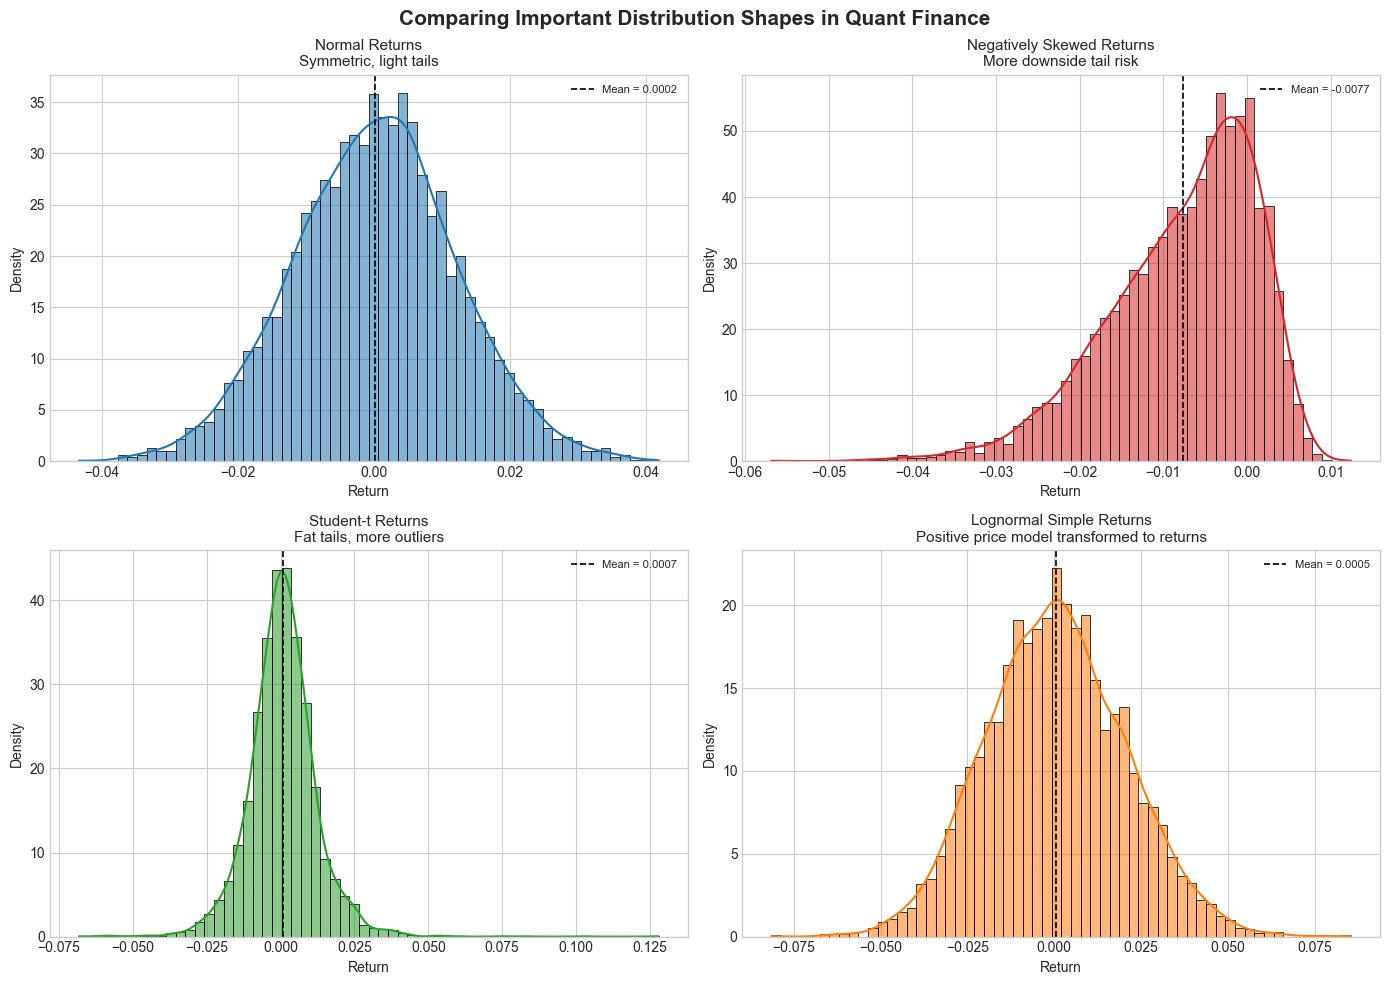

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Comparing Important Distribution Shapes in Quant Finance", fontsize=15, fontweight="bold")

plot_data = [
    (normal_returns, "Normal Returns", "#1f77b4", "Symmetric, light tails"),
    (skewed_returns, "Negatively Skewed Returns", "#d62728", "More downside tail risk"),
    (t_returns, "Student-t Returns", "#2ca02c", "Fat tails, more outliers"),
    (lognormal_simple_returns, "Lognormal Simple Returns", "#ff7f0e", "Positive price model transformed to returns"),
]

for ax, (series, title, color, subtitle) in zip(axes.flat, plot_data):
    sns.histplot(series, bins=60, stat="density", kde=True, color=color, alpha=0.55, ax=ax)
    ax.axvline(np.mean(series), color="black", linestyle="--", linewidth=1.2, label=f"Mean = {np.mean(series):.4f}")
    ax.set_title(f"{title}\n{subtitle}", fontsize=11)
    ax.set_xlabel("Return")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 4. Skewness and Kurtosis in Practice

Skewness and kurtosis are often more informative than just mean and volatility.

### How to read skewness

- **Negative skewness** means large downside moves are more common than large upside moves
- **Positive skewness** means the right tail is longer or more influential
- **Skewness near zero** means the left and right sides are more balanced

### How to read kurtosis

- **Kurtosis near 3** is normal-like
- **Kurtosis above 3** means fatter tails and more extreme moves
- **Very high kurtosis** is a warning that tail events matter a lot

### Beginner explanation

If volatility tells you how wide the road is, skewness tells you whether the road bends more to one side, and kurtosis tells you how likely it is that the road suddenly drops off a cliff.

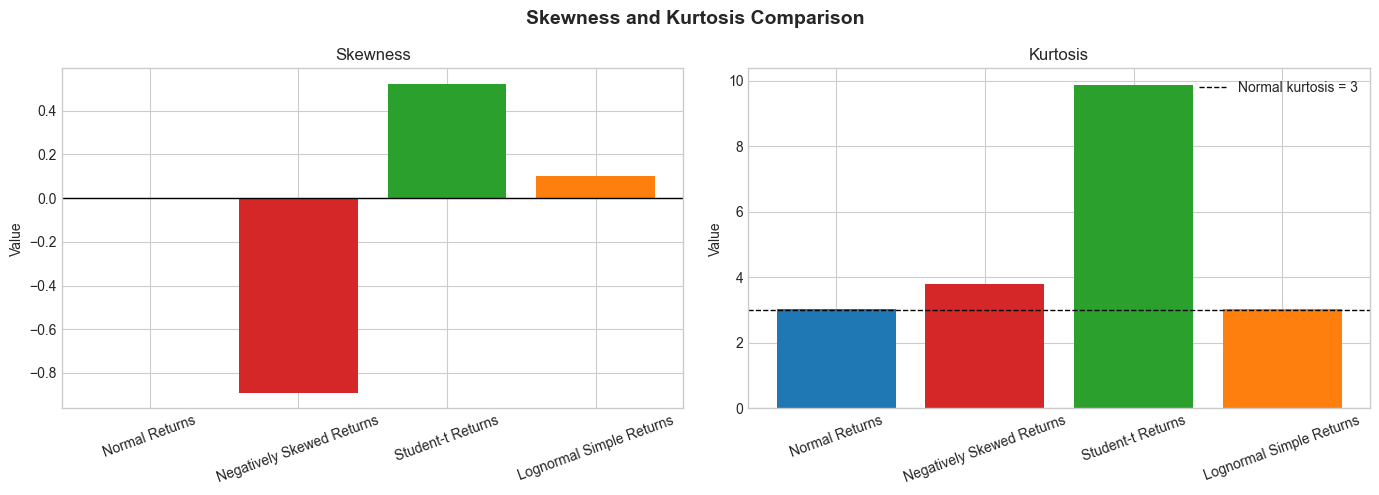

,Std Dev,P(|return - mean| > 2 own σ)
Normal,0.0120,4.68%
Skewed,0.0088,3.98%
Student-t,0.0115,5.20%


In [5]:
labels = list(summary_df.index)
skew_values = summary_df["Skewness"].values
kurt_values = summary_df["Kurtosis"].values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Skewness and Kurtosis Comparison", fontsize=14, fontweight="bold")

axes[0].bar(labels, skew_values, color=["#1f77b4", "#d62728", "#2ca02c", "#ff7f0e"])
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("Skewness")
axes[0].set_ylabel("Value")
axes[0].tick_params(axis="x", rotation=20)

axes[1].bar(labels, kurt_values, color=["#1f77b4", "#d62728", "#2ca02c", "#ff7f0e"])
axes[1].axhline(3, color="black", linestyle="--", linewidth=1, label="Normal kurtosis = 3")
axes[1].set_title("Kurtosis")
axes[1].set_ylabel("Value")
axes[1].tick_params(axis="x", rotation=20)
axes[1].legend()

plt.tight_layout()
plt.show()

tail_compare = pd.DataFrame({
    "Std Dev": [
        np.std(normal_returns, ddof=1),
        np.std(skewed_returns, ddof=1),
        np.std(t_returns, ddof=1),
    ],
    "P(|return - mean| > 2 own σ)": [
        np.mean(np.abs(normal_returns - np.mean(normal_returns)) > 2 * np.std(normal_returns, ddof=1)),
        np.mean(np.abs(skewed_returns - np.mean(skewed_returns)) > 2 * np.std(skewed_returns, ddof=1)),
        np.mean(np.abs(t_returns - np.mean(t_returns)) > 2 * np.std(t_returns, ddof=1)),
    ],
}, index=["Normal", "Skewed", "Student-t"])

tail_compare.style.format({
    "Std Dev": "{:.4f}",
    "P(|return - mean| > 2 own σ)": "{:.2%}",
})

## 5. How Quants Use Distribution Thinking

### In risk management

If returns are negatively skewed or have high kurtosis, risk models based only on normality can underestimate losses. This is one reason Value at Risk and stress testing need tail awareness.

### In derivatives

Option prices depend on how likely extreme price moves are. Volatility smiles and skews exist partly because real-world return distributions are not perfectly normal.

### In portfolio construction

Assets with similar average returns can still behave very differently in bad markets. Distribution shape helps compare them more realistically than mean return alone.

### Beginner explanation

A beginner mistake is to look only at average return and volatility. A better habit is to also ask:

- Is there downside asymmetry?
- Are extreme moves too frequent?
- Is a normal assumption clearly too optimistic?

## 6. Quick Summary

- A **distribution** describes how outcomes are spread out
- The **normal distribution** is the clean benchmark, but real markets often deviate from it
- **Lognormal** shapes are natural for prices because prices stay positive
- **Skewness** shows whether the left or right tail dominates
- **Kurtosis** shows how important extreme outcomes are
- In quant finance, skewness and kurtosis matter because risk often lives in the tails, not in the average

### Final beginner takeaway

When looking at any return series, first ask three questions: is it symmetric, does it have fat tails, and does it hide downside tail risk? Those three checks already make your analysis much more realistic.